# 1. Perkenalan Dataset

Proyek ini menggunakan Heart Disease Dataset yang bersumber dari UCI Machine Learning Repository / Kaggle. Dataset ini terdiri dari 14 fitur utama (seperti usia, jenis kelamin, tekanan darah, kolesterol, dll) dengan target biner 1 (memiliki penyakit jantung) dan 0 (normal/sehat).

# 2. Import Library

In [1]:
# Masukkan kode ini di cell di bawah heading 2
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("Library berhasil di-import!")

Library berhasil di-import!


# 3. Memuat Dataset

In [5]:
import os
import pandas as pd

# 1. Tentukan path data
base_dir = r"C:\Users\alfin\Eksperimen_SML_MuhamadRizal"
folder_path = os.path.join(base_dir, "namadataset_raw")
data_path = os.path.join(folder_path, "heart.csv")

# 2. Cek apakah folder 'heart_disease_raw' sudah ada? Kalau belum, buat otomatis!
if not os.path.exists(folder_path):
    os.makedirs(folder_path)
    print(f"⚠️ Folder baru saja dibuat otomatis! Silakan taruh file 'heart.csv' kamu di sini:\n➡️ {folder_path}\n")
else:
    print(f"✅ Folder terdeteksi di: {folder_path}")

# 3. Cek apakah file 'heart.csv' sudah ada di dalam folder?
if os.path.exists(data_path):
    print("✅ Berkas 'heart.csv' DITEMUKAN! Membaca data...")
    df = pd.read_csv(data_path)
    print("\n5 Baris Pertama Dataset:")
    print(df.head())
else:
    print(f"❌ Berkas 'heart.csv' BELUM ADA di folder tersebut.")
    print(f"Silakan unduh dataset Heart Disease, beri nama 'heart.csv' (pastikan huruf kecil semua), lalu pindahkan ke: {folder_path}")

✅ Folder terdeteksi di: C:\Users\alfin\Eksperimen_SML_MuhamadRizal\namadataset_raw
✅ Berkas 'heart.csv' DITEMUKAN! Membaca data...

5 Baris Pertama Dataset:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


# 4. Exploratory Data Analysis (EDA)

--- Informasi Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

--- Statistik Deskriptif ---
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     

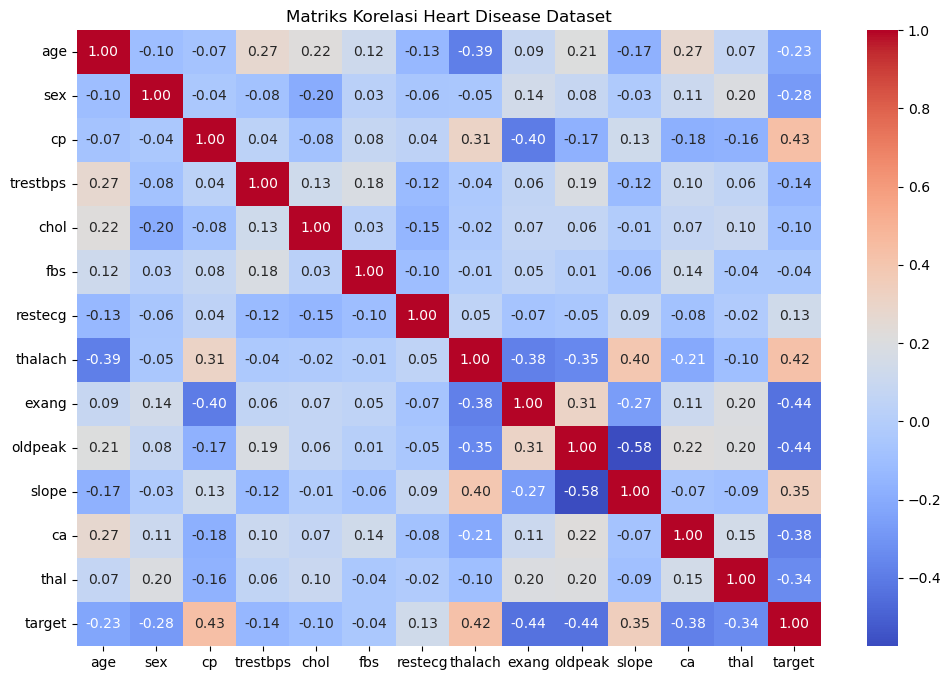

In [6]:
# 1. Memeriksa informasi umum dataset (Tipe data dan Missing Values)
print("--- Informasi Dataset ---")
print(df.info())

# 2. Memeriksa Statistik Deskriptif data numerik
print("\n--- Statistik Deskriptif ---")
print(df.describe())

# 3. Memeriksa distribusi kelas target (Penting untuk monitoring nantinya)
print("\n--- Distribusi Kelas Target ---")
print(df['target'].value_counts())

# 4. Visualisasi singkat korelasi antar fitur
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriks Korelasi Heart Disease Dataset')
plt.show()

# 5. Data Preprocessing

In [ ]:
# 1. Penanganan Missing Values & Duplikat (Sesuai Karakteristik Data)
df = df.dropna()
df = df.drop_duplicates()

# 2. Memisahkan Fitur (X) dan Target (y)
X = df.drop(columns=['target'])
y = df['target']

# 3. Membagi data menjadi Train set dan Test set (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Standarisasi Fitur Numerik menggunakan StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Mengembalikan ke bentuk DataFrame agar rapi saat disimpan ke CSV
X_train_final = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X.columns)

# 5. Membuat direktori output dan menyimpan hasil preprocessing
output_dir = "namadataset_preprocessing"
os.makedirs(output_dir, exist_ok=True)

X_train_final.to_csv(f"{output_dir}/X_train.csv", index=False)
X_test_final.to_csv(f"{output_dir}/X_test.csv", index=False)
y_train.to_csv(f"{output_dir}/y_train.csv", index=False)
y_test.to_csv(f"{output_dir}/y_test.csv", index=False)

print(f"Data preprocessing selesai! Berkas disimpan di folder '{output_dir}/'")

Data preprocessing selesai! Berkas disimpan di folder 'heart_disease_preprocessing/'
